<a href="https://colab.research.google.com/github/thirumurugan1305/Loan_approval_screening.py/blob/main/loan_approval_screening_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset_02_loan_approval_screening.csv to dataset_02_loan_approval_screening.csv


In [ ]:
import pandas as pd

df = pd.read_csv("dataset_02_loan_approval_screening.csv")

df.head()

,income_monthly,credit_score,debt_to_income,employment_years,loan_amount,prior_defaults,target
0,183.46,826.0,91.27,12.31,316.64,5,0
1,210.10,664.0,93.23,6.05,122.07,2,1
2,58.07,594.0,277.85,1.05,170.48,4,0
3,165.98,724.0,97.53,0.00,146.82,2,1
4,77.82,600.0,39.69,8.24,213.94,3,0


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape:
(1000, 7)

Column Names:
['income_monthly', 'credit_score', 'debt_to_income', 'employment_years', 'loan_amount', 'prior_defaults', 'target']


In [ ]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   income_monthly    1000 non-null   float64
 1   credit_score      1000 non-null   float64
 2   debt_to_income    1000 non-null   float64
 3   employment_years  1000 non-null   float64
 4   loan_amount       1000 non-null   float64
 5   prior_defaults    1000 non-null   int64  
 6   target            1000 non-null   int64  
dtypes: float64(5), int64(2)
memory usage: 54.8 KB


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
income_monthly      0
credit_score        0
debt_to_income      0
employment_years    0
loan_amount         0
prior_defaults      0
target              0
dtype: int64


In [ ]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
0


In [ ]:
df = df.drop_duplicates()

df = df.dropna()

print("Dataset Shape After Cleaning:")
print(df.shape)

Dataset Shape After Cleaning:
(1000, 7)


In [ ]:
print("Target Distribution:")
print(df["target"].value_counts())

print("\nTarget Distribution (%):")
print(df["target"].value_counts(normalize=True) * 100)

Target Distribution:
target
0    500
1    500
Name: count, dtype: int64

Target Distribution (%):
target
0    50.0
1    50.0
Name: proportion, dtype: float64


In [ ]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
       income_monthly  credit_score  debt_to_income  employment_years  \
count     1000.000000   1000.000000     1000.000000       1000.000000   
mean       187.527780    679.694000      184.807450          5.227470   
std        142.348587     67.436712      136.389002          3.708741   
min         19.220000    485.000000       11.450000          0.000000   
25%         88.630000    636.000000       88.495000          2.305000   
50%        147.915000    680.000000      145.615000          4.995000   
75%        236.370000    725.000000      237.570000          7.692500   
max       1011.220000    850.000000     1095.030000         17.410000   

       loan_amount  prior_defaults      target  
count  1000.000000     1000.000000  1000.00000  
mean    190.726710        2.939000     0.50000  
std     149.615795        1.718206     0.50025  
min      15.060000        0.000000     0.00000  
25%      93.770000        2.000000     0.00000  
50%     148.655000        3

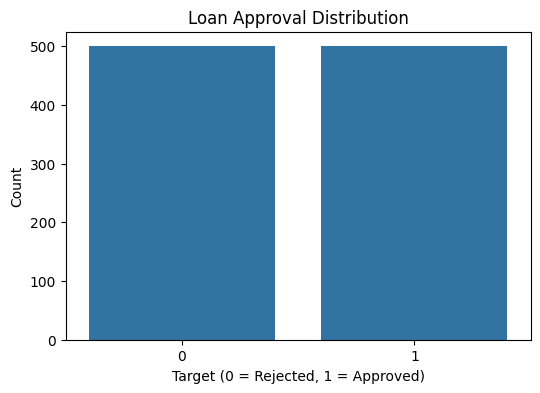

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="target")

plt.title("Loan Approval Distribution")
plt.xlabel("Target (0 = Rejected, 1 = Approved)")
plt.ylabel("Count")

plt.show()

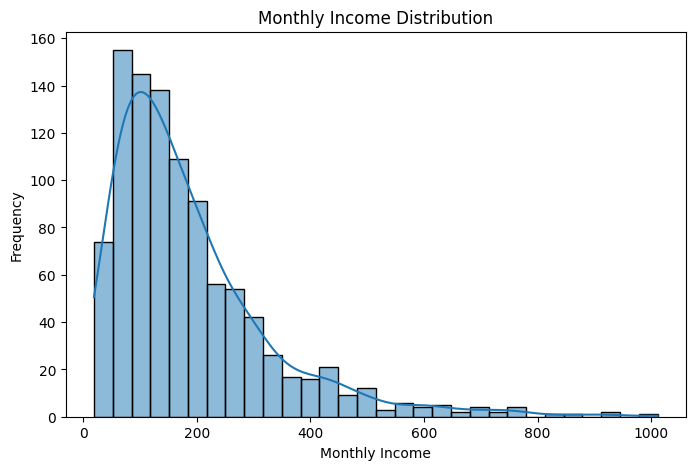

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["income_monthly"], bins=30, kde=True)

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")

plt.show()

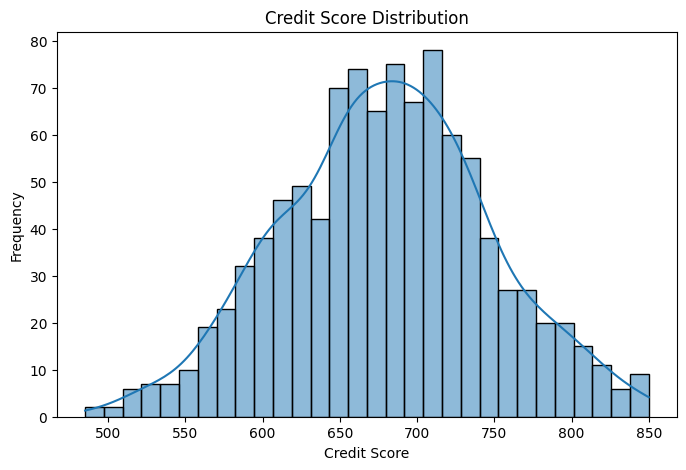

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["credit_score"], bins=30, kde=True)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.show()

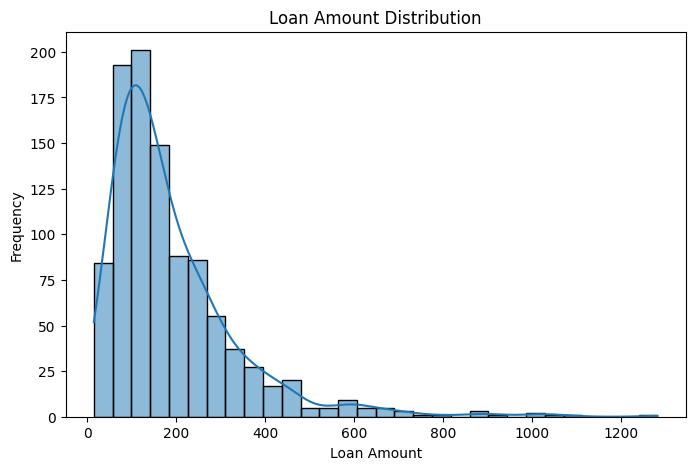

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["loan_amount"], bins=30, kde=True)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

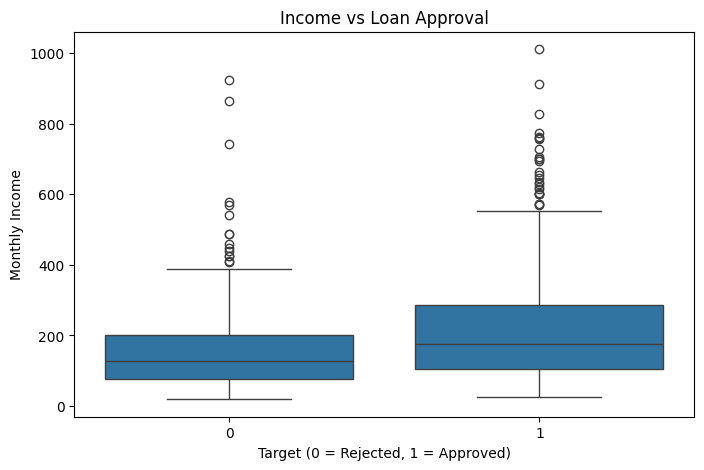

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="target", y="income_monthly")

plt.title("Income vs Loan Approval")
plt.xlabel("Target (0 = Rejected, 1 = Approved)")
plt.ylabel("Monthly Income")

plt.show()

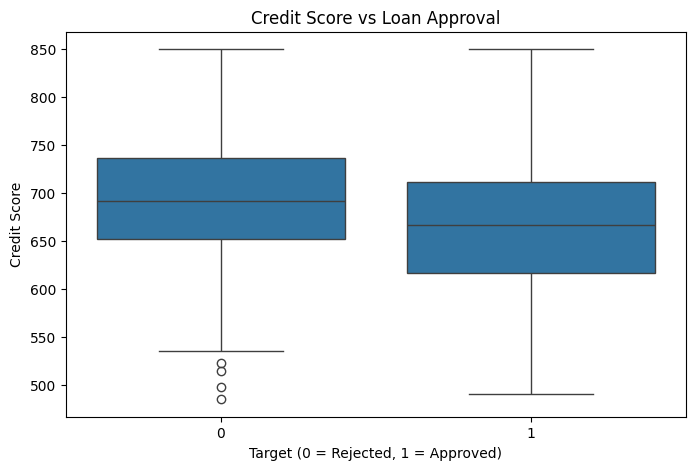

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="target", y="credit_score")

plt.title("Credit Score vs Loan Approval")
plt.xlabel("Target (0 = Rejected, 1 = Approved)")
plt.ylabel("Credit Score")

plt.show()

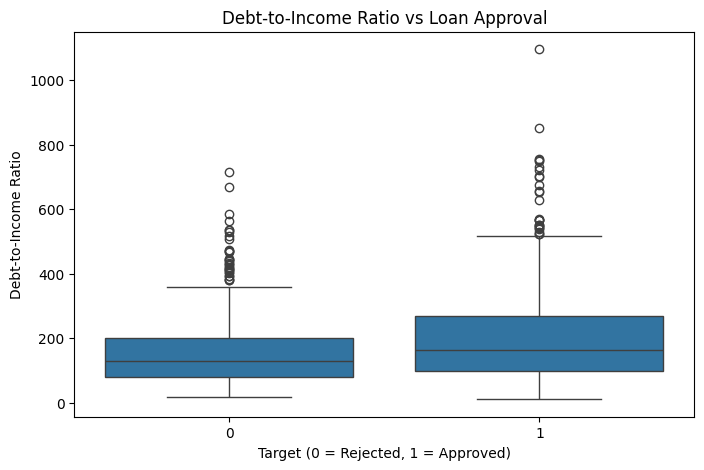

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="target", y="debt_to_income")

plt.title("Debt-to-Income Ratio vs Loan Approval")
plt.xlabel("Target (0 = Rejected, 1 = Approved)")
plt.ylabel("Debt-to-Income Ratio")

plt.show()

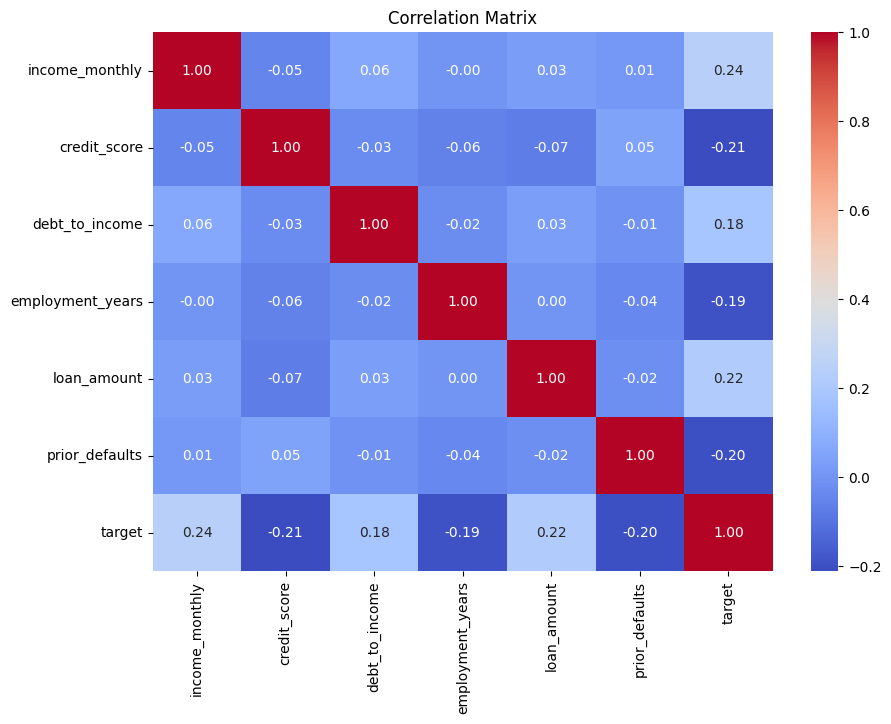

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['income_monthly', 'credit_score', 'debt_to_income', 'employment_years', 'loan_amount', 'prior_defaults']

Target:
target


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

Training Data Shape:
(800, 6)

Testing Data Shape:
(200, 6)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("       LOAN APPROVAL MODEL PERFORMANCE")
print("=" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Rejected", "Approved"]
))

print("=" * 50)
print("CONFUSION MATRIX")
print("=" * 50)

cm = confusion_matrix(y_test, y_pred)
print(cm)

       LOAN APPROVAL MODEL PERFORMANCE
Accuracy  : 0.7050
Precision : 0.6881
Recall    : 0.7500
F1 Score  : 0.7177
ROC-AUC   : 0.7823

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Rejected       0.73      0.66      0.69       100
    Approved       0.69      0.75      0.72       100

    accuracy                           0.70       200
   macro avg       0.71      0.71      0.70       200
weighted avg       0.71      0.70      0.70       200

CONFUSION MATRIX
[[66 34]
 [25 75]]


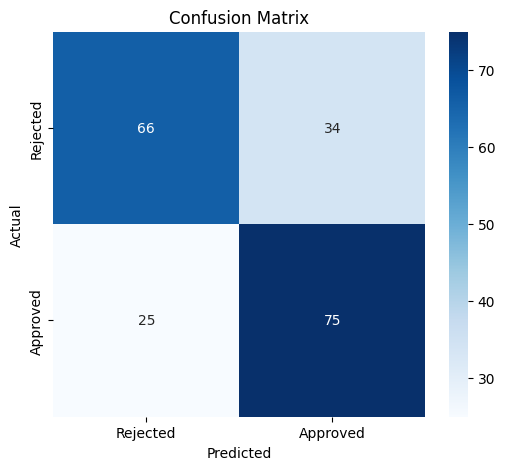

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

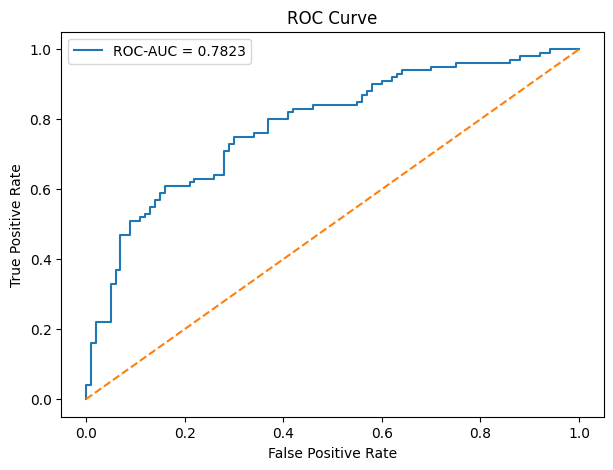

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print(feature_importance)

            Feature  Coefficient  Absolute_Coefficient
3  employment_years    -0.608752              0.608752
4       loan_amount     0.594229              0.594229
0    income_monthly     0.585141              0.585141
1      credit_score    -0.524847              0.524847
5    prior_defaults    -0.515878              0.515878
2    debt_to_income     0.434223              0.434223


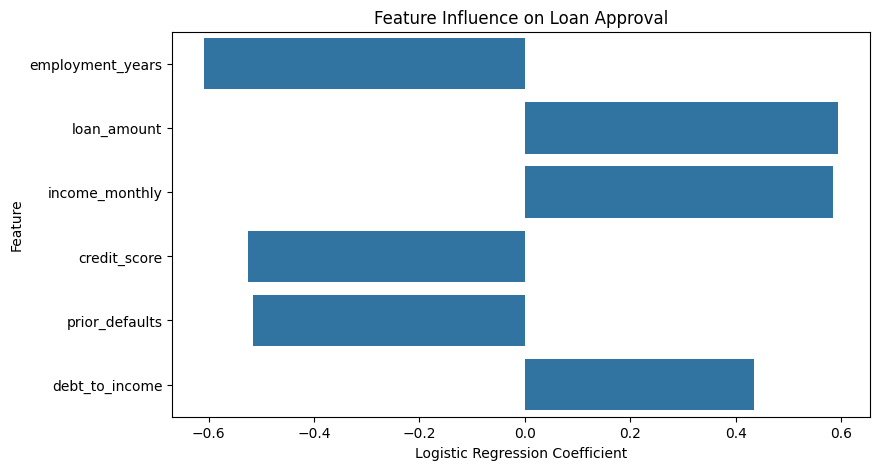

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Influence on Loan Approval")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.show()

In [ ]:
new_applicants = pd.DataFrame({
    "income_monthly": [60000, 25000],
    "credit_score": [750, 550],
    "debt_to_income": [0.25, 0.65],
    "employment_years": [5, 1],
    "loan_amount": [200000, 500000],
    "prior_defaults": [0, 2]
})

new_applicants_scaled = scaler.transform(new_applicants)

new_predictions = model.predict(new_applicants_scaled)

new_probabilities = model.predict_proba(
    new_applicants_scaled
)[:, 1]

results = new_applicants.copy()

results["Prediction"] = new_predictions
results["Decision"] = results["Prediction"].map({
    0: "Rejected",
    1: "Approved"
})

results["Approval_Probability"] = new_probabilities

print("NEW APPLICANT PREDICTIONS")
print("=" * 60)

print(results)

NEW APPLICANT PREDICTIONS
   income_monthly  credit_score  debt_to_income  employment_years  \
0           60000           750            0.25                 5   
1           25000           550            0.65                 1   

   loan_amount  prior_defaults  Prediction  Decision  Approval_Probability  
0       200000               0           1  Approved                   1.0  
1       500000               2           1  Approved                   1.0  


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("       LOAN APPROVAL MODEL PERFORMANCE")
print("=" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Rejected", "Approved"]
))

print("=" * 50)
print("CONFUSION MATRIX")
print("=" * 50)

cm = confusion_matrix(y_test, y_pred)
print(cm)

       LOAN APPROVAL MODEL PERFORMANCE
Accuracy  : 0.7050
Precision : 0.6881
Recall    : 0.7500
F1 Score  : 0.7177
ROC-AUC   : 0.7823

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Rejected       0.73      0.66      0.69       100
    Approved       0.69      0.75      0.72       100

    accuracy                           0.70       200
   macro avg       0.71      0.71      0.70       200
weighted avg       0.71      0.70      0.70       200

CONFUSION MATRIX
[[66 34]
 [25 75]]


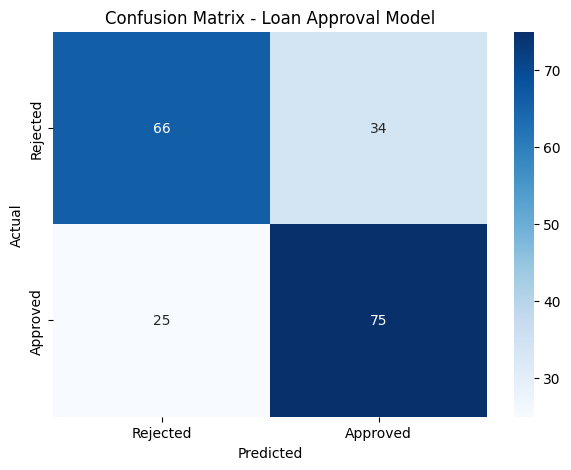

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Confusion Matrix - Loan Approval Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

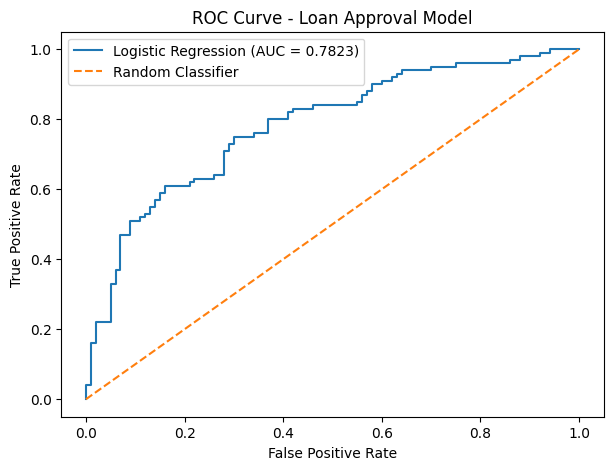

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Loan Approval Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("FEATURE INFLUENCE")
print("=" * 50)
print(feature_importance)

FEATURE INFLUENCE
            Feature  Coefficient  Absolute_Coefficient
3  employment_years    -0.608752              0.608752
4       loan_amount     0.594229              0.594229
0    income_monthly     0.585141              0.585141
1      credit_score    -0.524847              0.524847
5    prior_defaults    -0.515878              0.515878
2    debt_to_income     0.434223              0.434223


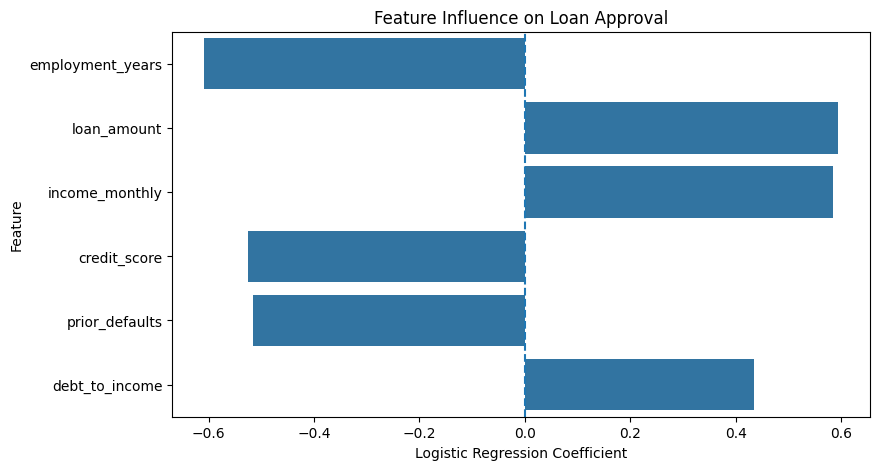

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Influence on Loan Approval")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.axvline(0, linestyle="--")

plt.show()

In [ ]:
new_applicants = pd.DataFrame({
    "income_monthly": [60000, 25000],
    "credit_score": [750, 550],
    "debt_to_income": [0.25, 0.65],
    "employment_years": [5, 1],
    "loan_amount": [200000, 500000],
    "prior_defaults": [0, 2]
})

new_applicants_scaled = scaler.transform(new_applicants)

new_predictions = model.predict(new_applicants_scaled)

new_probabilities = model.predict_proba(
    new_applicants_scaled
)[:, 1]

results = new_applicants.copy()

results["Prediction"] = new_predictions

results["Decision"] = results["Prediction"].map({
    0: "Rejected",
    1: "Approved"
})

results["Approval_Probability"] = new_probabilities

print("NEW APPLICANT PREDICTIONS")
print("=" * 70)

print(results.to_string(index=False))

NEW APPLICANT PREDICTIONS
 income_monthly  credit_score  debt_to_income  employment_years  loan_amount  prior_defaults  Prediction Decision  Approval_Probability
          60000           750            0.25                 5       200000               0           1 Approved                   1.0
          25000           550            0.65                 1       500000               2           1 Approved                   1.0


# Loan Approval Screening Using Machine Learning

## Project Objective

The objective of this project is to develop a machine learning model that predicts whether a loan application should be approved or rejected based on applicant financial and employment information.

## Dataset Features

The model uses the following features:

- Monthly Income
- Credit Score
- Debt-to-Income Ratio
- Employment Years
- Loan Amount
- Prior Defaults

The target variable is:

- 0 → Rejected
- 1 → Approved

## Methodology

The project follows these steps:

1. Dataset loading
2. Data inspection
3. Data cleaning
4. Exploratory Data Analysis
5. Feature and target separation
6. Train-test splitting
7. Feature scaling using StandardScaler
8. Logistic Regression model training
9. Prediction
10. Model evaluation
11. Confusion Matrix analysis
12. ROC Curve analysis
13. Feature influence analysis
14. New applicant prediction

## Machine Learning Algorithm

Logistic Regression was used as the classification algorithm to predict loan approval.

## Model Performance

- Accuracy: 70.50%
- Precision: 68.81%
- Recall: 75.00%
- F1 Score: 71.77%
- ROC-AUC: 78.23%

## Conclusion

The Logistic Regression model achieved an accuracy of approximately 70.5% and an ROC-AUC score of 0.7823. The model demonstrates a reasonable ability to distinguish between approved and rejected loan applications.

The model can be used as a screening or decision-support system, but it should not be treated as the sole basis for real-world lending decisions.